<center>

# STK4051 - Computational Statistics

## Mandatory Assignment 2 

### John-Magnus Johnsen

#### University of Oslo

##### April 16, 2026

</center>

## Problem 1.

### a)

The probability density function (PDF) for the exponential distribution is given by:

$$
f(x) = \lambda e^{-\lambda x}
$$

where $\lambda$ is the parameter of the distribution, called the *rate parameter*.

The mean is given by:

$$
\mu = \mathrm{E}[X] = \frac{1}{\lambda}
$$

Since we have $\lambda = \theta^{-1}$ the PDF takes the form:

$$
f(x) = \theta^{-1} e^{-x/\theta}
$$

And the mean becomes:

$$
\mu = \theta
$$

### b)

In [231]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Setting global seed
rng = np.random.default_rng(seed=42)

In [207]:
n = 100
theta = 1.0

original_sample = rng.exponential(scale=theta, size=n)

In [208]:
theta_hat = np.mean(original_sample)
theta_hat

np.float64(0.8990538933419093)

In [189]:
n_bootstraps = 1000

bootstraps = np.zeros([n_bootstraps])

for i in range(n_bootstraps):
    bootstrap_sample = rng.exponential(scale=theta_hat, size=n)
    bootstraps[i] = np.mean(bootstrap_sample)

In [195]:
np.mean(bootstraps)

np.float64(0.9022170512576301)

In [228]:
np.sum(rng.normal(theta_hat, theta_hat/n, size=n)**2)/(2*n)

np.float64(0.40238446294705105)

In [209]:
(original_sample**2)/(2*n)

array([2.89010951e-02, 2.72889105e-02, 2.84354251e-02, 3.91424223e-04,
       3.73571203e-05, 1.05511129e-02, 9.93994580e-03, 4.88061261e-02,
       3.14378485e-05, 5.47644803e-03, 2.48063666e-05, 5.92986231e-03,
       1.49874720e-02, 7.48438026e-04, 7.58401622e-03, 1.18231068e-04,
       4.19319795e-05, 4.96689647e-04, 4.06080067e-03, 8.52784413e-04,
       7.77985854e-03, 2.49931971e-04, 1.68906735e-02, 7.52869858e-03,
       2.15034298e-03, 8.69806603e-04, 1.02749370e-03, 2.97044330e-05,
       1.61338734e-04, 2.34832061e-03, 7.55361630e-04, 7.99109489e-03,
       2.50979485e-03, 2.83053316e-04, 1.06301227e-03, 2.05797524e-03,
       5.91106902e-04, 5.18134171e-04, 3.86245509e-03, 4.40888224e-04,
       8.89381079e-03, 9.67251314e-03, 5.87617897e-03, 2.66656980e-05,
       6.43054549e-03, 9.17115693e-03, 6.29486490e-03, 3.92137549e-04,
       5.15000194e-04, 1.37341955e-04, 6.27867496e-04, 2.23444651e-06,
       1.40040817e-04, 8.64687252e-03, 7.98303409e-02, 1.58787591e-03,
      

(array([  7.,  28., 102., 236., 268., 212., 101.,  36.,   8.,   2.]),
 array([0.62522724, 0.68666692, 0.74810661, 0.80954629, 0.87098598,
        0.93242566, 0.99386534, 1.05530503, 1.11674471, 1.17818439,
        1.23962408]),
 <BarContainer object of 10 artists>)

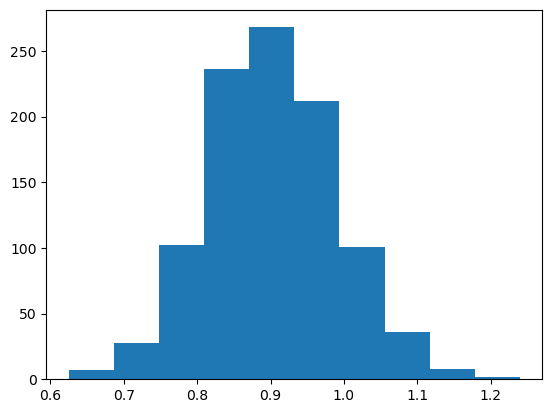

In [230]:
plt.hist(bootstraps)

## Problem 2.

### a)

In [248]:
df = pd.read_csv("discoveries.csv", sep=",", dtype=int)
categories = df.columns.tolist()
data = df.to_numpy()

In [250]:
df.head

<bound method NDFrame.head of     Year  Count
0   1860      5
1   1861      3
2   1862      0
3   1863      2
4   1864      0
..   ...    ...
95  1955      1
96  1956      0
97  1957      0
98  1958      2
99  1959      0

[100 rows x 2 columns]>

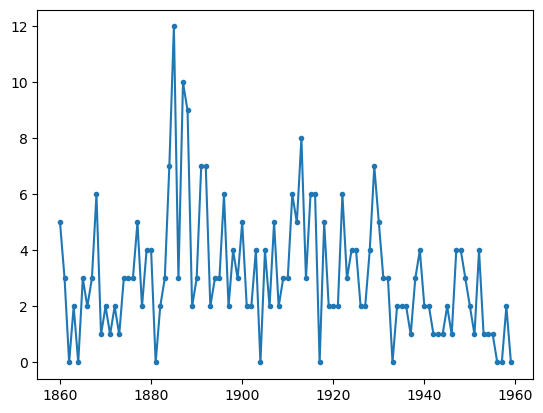

In [259]:
years = data[:,0]
discoveries = data[:,1]

plt.plot(years, discoveries, ".-")